In [3]:
import pandas as pd
import numpy as np

In [4]:
data = pd.read_csv("/content/OnlinePaymentFraudDetection.csv")
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
data.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [6]:
# Exploring transaction type
data.type.value_counts()

,count
type,
CASH_OUT,2237500
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,532909
DEBIT,41432


In [7]:
type = data["type"].value_counts()
transactions = type.index
quantity = type.values

import plotly.express as px
figure = px.pie(data,
             values=quantity,
             names=transactions,hole = 0.5,
             title="Distribution of Transaction Type")
figure.show()

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fraud vs Non-Fraud Class Distribution
fraud_counts = data['isFraud'].value_counts()
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette=['steelblue', 'tomato'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title('Fraud vs Non-Fraud Transactions', fontsize=14)
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

NameError: name 'data' is not defined

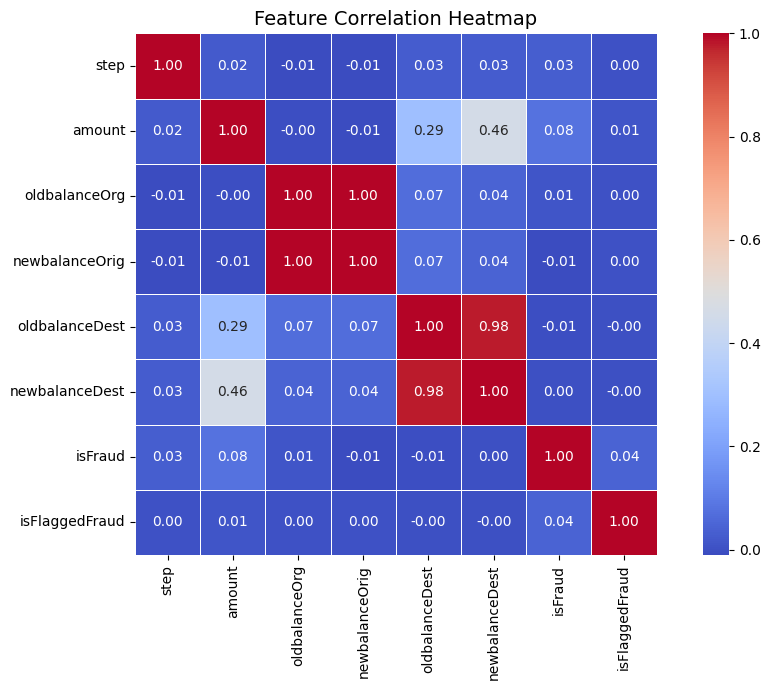

In [8]:
# 3. Correlation Heatmap (numeric columns)
numeric_data = data.select_dtypes(include='number')
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_data.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
data["type"] = data["type"].map({"CASH_OUT": 1, "PAYMENT": 2,
                                 "CASH_IN": 3, "TRANSFER": 4,
                                 "DEBIT": 5})
# The 'isFraud' column should remain numerical (0 or 1) for the target variable.
# So, we remove the line that maps it to strings.
# data["isFraud"] = data["isFraud"].map({0: "No Fraud", 1: "Fraud"})
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,2,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,2,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,4,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,2,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [10]:
# splitting the data
print(data.columns)

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')


In [19]:
# Drop 'nameOrig' and 'nameDest' columns if they exist
columns_to_drop = ["nameOrig", "nameDest"]
existing_columns_to_drop = [col for col in columns_to_drop if col in data.columns]
if existing_columns_to_drop:
    data = data.drop(existing_columns_to_drop, axis=1)

# At this point, all remaining columns are numerical, so pd.get_dummies is not needed.
# If there were other categorical columns apart from 'type', 'nameOrig', 'nameDest', they would be handled here.

In [20]:
x = data.drop("isFraud", axis=1)
y = data["isFraud"]

In [13]:
from sklearn.model_selection import train_test_split

In [21]:
from sklearn.tree import DecisionTreeClassifier
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.20, random_state=42)
model = DecisionTreeClassifier()
model.fit(xtrain, ytrain)
model.score(xtest, ytest)

0.9997084534358488

In [22]:
import pickle

# save
with open("fraud_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [26]:
# load
with open("fraud_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

In [33]:
import warnings
from sklearn.utils.validation import DataConversionWarning

# Ignore the specific UserWarning from sklearn about feature names
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning, module='sklearn.utils.validation')
    # prediction
    #features = [type, amount, oldbalanceOrg, newbalanceOrig]
    features = np.array([[1, 4, 9000.60, 9000.60, 0.0, 0.0, 0.0, 0]])
    model_prediction = loaded_model.predict(features) # Use loaded_model instead of model
    if model_prediction == 1:
        print("Fraud")
    else:
        print("Not Fraud")

Fraud
